# Zadanie 3 Regresja: California Housing

**Cel:** przewidywanie mediany ceny domu (`MedHouseVal`, w setkach tys. USD) na podstawie 8 cech.

**Zbiór:** `sklearn.datasets.fetch_california_housing` (20 640 próbek, 8 cech).

## 1. Importy i konfiguracja

In [ ]:
from Wspolne import ustaw_seed, wykres_krzywych_uczenia, metryki_regresji, wykres_predykcja_vs_prawdziwa, tabela_porownawcza
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

ustaw_seed(42) 

## 2. Wczytanie i poznanie danych 

In [6]:
dane = fetch_california_housing(as_frame=True)
df = dane.frame
print("Wymiar:", df.shape)
print("Cechy:", list(dane.feature_names))
df.head()

Wymiar: (20640, 9)
Cechy: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
print(df.describe().round(2))

         MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  MedHouseVal
count  20640.00  20640.00  20640.00  ...  20640.00   20640.00     20640.00
mean       3.87     28.64      5.43  ...     35.63    -119.57         2.07
std        1.90     12.59      2.47  ...      2.14       2.00         1.15
min        0.50      1.00      0.85  ...     32.54    -124.35         0.15
25%        2.56     18.00      4.44  ...     33.93    -121.80         1.20
50%        3.53     29.00      5.23  ...     34.26    -118.49         1.80
75%        4.74     37.00      6.05  ...     37.71    -118.01         2.65
max       15.00     52.00    141.91  ...     41.95    -114.31         5.00

[8 rows x 9 columns]


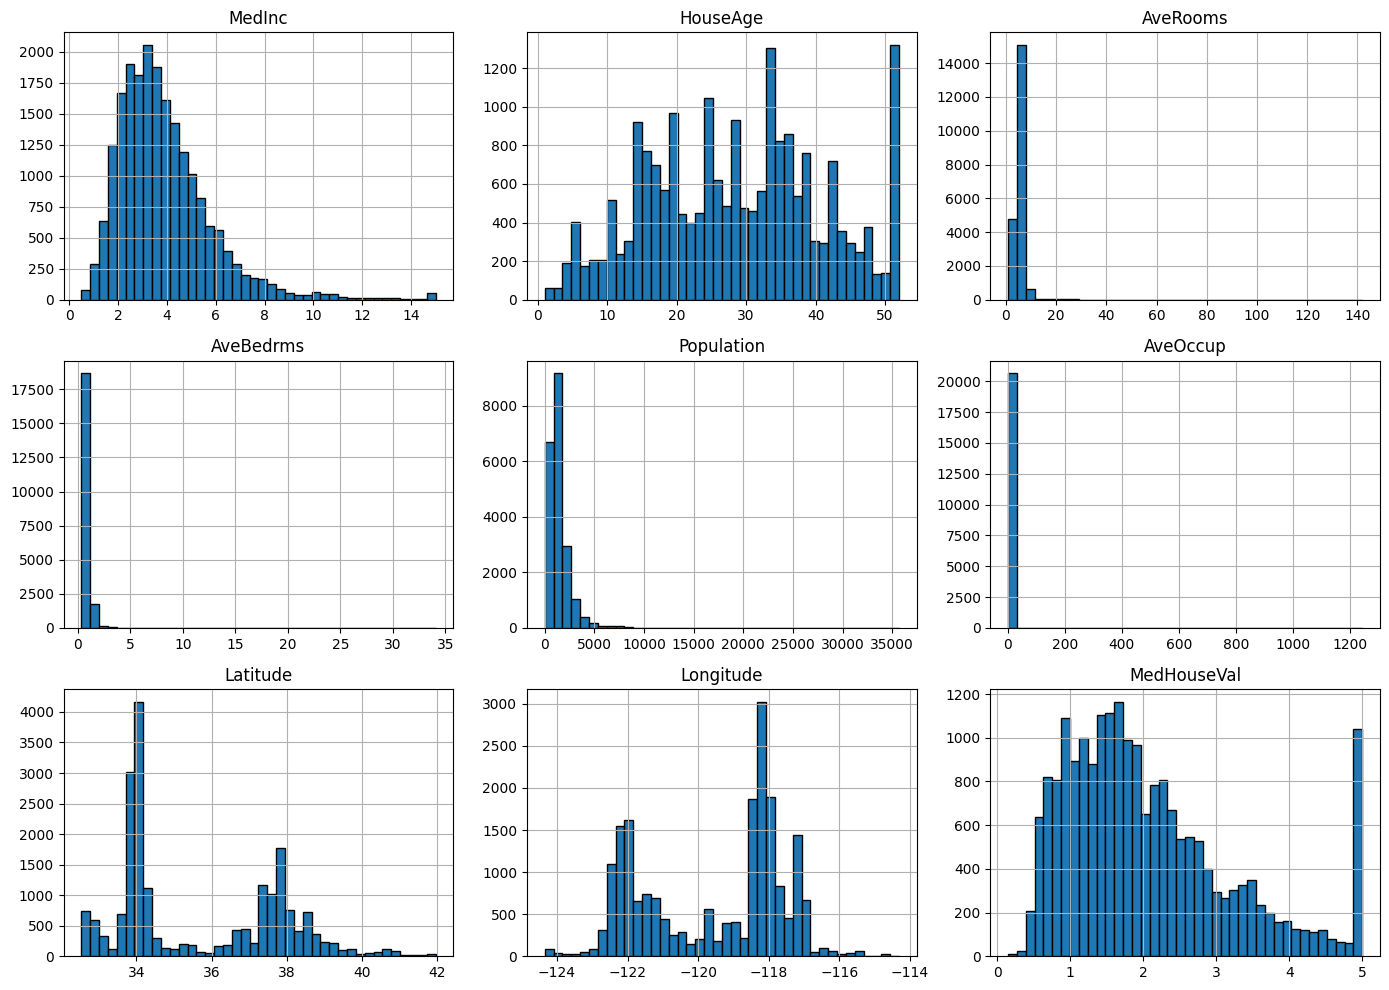

In [9]:
df.hist(figsize=(14, 10), bins=40, edgecolor='black')
plt.tight_layout()
plt.show()

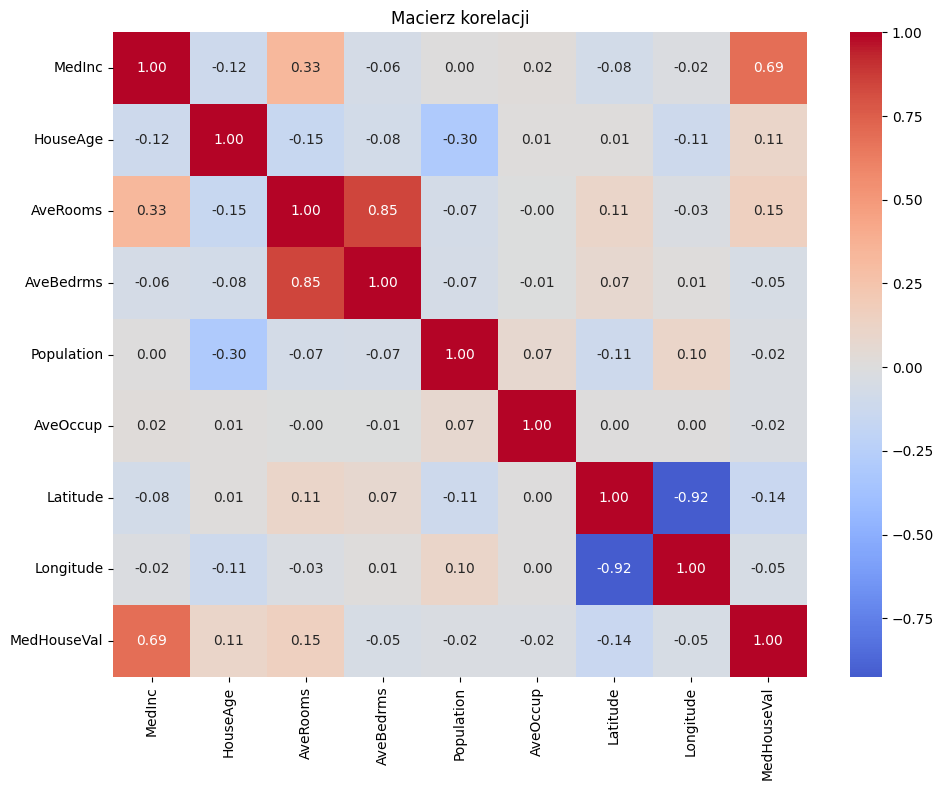

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Macierz korelacji')
plt.tight_layout()
plt.show()

## 3. Przygotowanie danych

Podział 60/20/20 i skalowanie cech (`StandardScaler` dopasowany tylko na zbiorze uczącym).
Target zostawiamy w oryginalnej skali, dzięki czemu metryki są w setkach tys. USD.

In [11]:
X = df[dane.feature_names].values
y = df['MedHouseVal'].values

# Podział 60/20/20
X_train, X_reszta, y_train, y_reszta = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_reszta, y_reszta, test_size=0.5, random_state=42)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

skaler = StandardScaler()
X_train = skaler.fit_transform(X_train)
X_val = skaler.transform(X_val)
X_test = skaler.transform(X_test)

Train: (12384, 8) Val: (4128, 8) Test: (4128, 8)


## 4. Funkcje pomocnicze

`buduj_mlp` tworzy sieć wg listy warstw, `trenuj` ją uczy, `oblicz_metryki` ocenia na zbiorze testowym.

In [13]:
def buduj_mlp(warstwy=(64, 32), dropout=0.0, batchnorm=False):
    model = Sequential()
    model.add(layers.Input((8,)))           
    for n in warstwy:
        model.add(layers.Dense(n))
        if batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))              
    return model


def trenuj(model, optimizer='adam'):
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    return model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200, batch_size=64, callbacks=[stop], verbose=0)


def oblicz_metryki(model):
    pred = model.predict(X_test, verbose=0).ravel()
    return metryki_regresji(y_test, pred)


wyniki = {}  

## 5. Model bazowy: regresja liniowa

In [14]:
model_liniowy = LinearRegression().fit(X_train, y_train)
pred_liniowy = model_liniowy.predict(X_test)
wyniki['Regresja liniowa'] = metryki_regresji(y_test, pred_liniowy)
print(wyniki['Regresja liniowa'])

{'MSE': 0.5546246533101034, 'RMSE': 0.7447312624766758, 'MAE': 0.5337565587311199, 'R2': 0.5954968710766684}


## 6. Model: prosty MLP

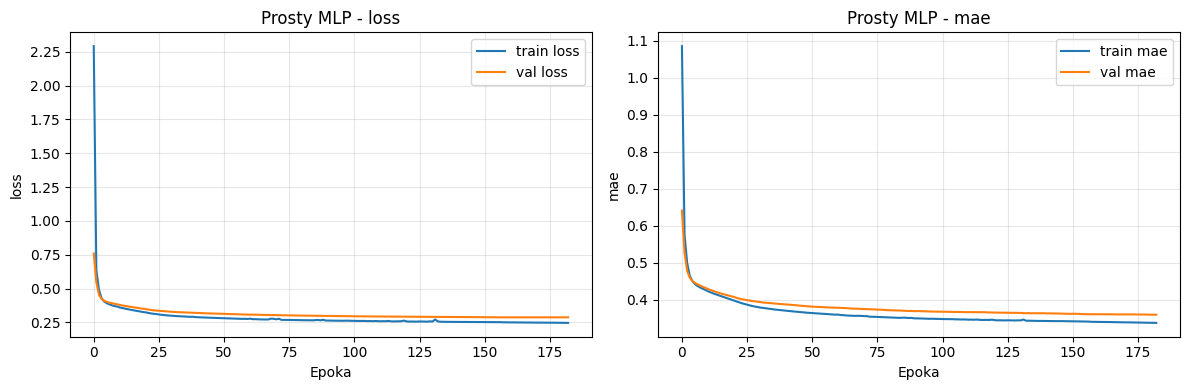

{'MSE': 0.27778617154216134, 'RMSE': 0.5270542396586535, 'MAE': 0.35527258588353094, 'R2': 0.7974028473313978}


In [15]:
model_maly = buduj_mlp(warstwy=(32, 16))
historia = trenuj(model_maly)
wykres_krzywych_uczenia(historia, metryki=('loss', 'mae'), tytul='Prosty MLP')
wyniki['MLP prosty'] = oblicz_metryki(model_maly)
print(wyniki['MLP prosty'])

## 7. Model: MLP z Dropoutem

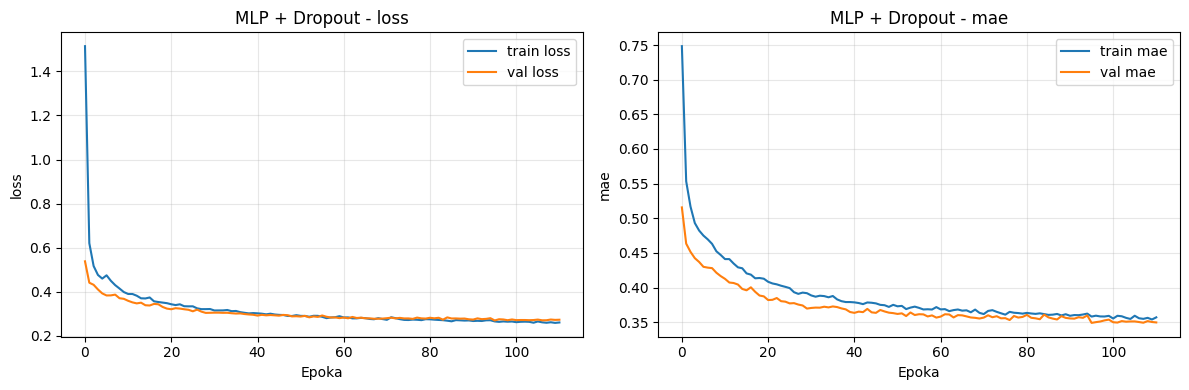

{'MSE': 0.26136181048756524, 'RMSE': 0.5112355724004006, 'MAE': 0.34180699664866737, 'R2': 0.8093815889857756}


In [16]:
model_dropout = buduj_mlp(warstwy=(128, 64), dropout=0.2)
historia = trenuj(model_dropout)
wykres_krzywych_uczenia(historia, metryki=('loss', 'mae'), tytul='MLP + Dropout')
wyniki['MLP Dropout'] = oblicz_metryki(model_dropout)
print(wyniki['MLP Dropout'])

## 8. Model: MLP z BatchNorm

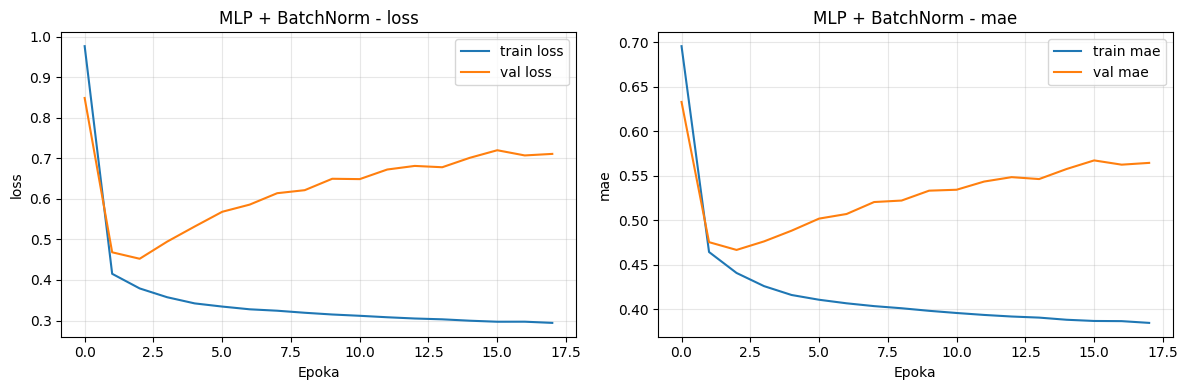

{'MSE': 0.46741864831574564, 'RMSE': 0.6836802237272522, 'MAE': 0.47167896843811574, 'R2': 0.6590986270941714}


In [17]:
model_bn = buduj_mlp(warstwy=(128, 64), batchnorm=True)
historia = trenuj(model_bn)
wykres_krzywych_uczenia(historia, metryki=('loss', 'mae'), tytul='MLP + BatchNorm')
wyniki['MLP BatchNorm'] = oblicz_metryki(model_bn)
print(wyniki['MLP BatchNorm'])

## 9. Porównanie optymalizatorów

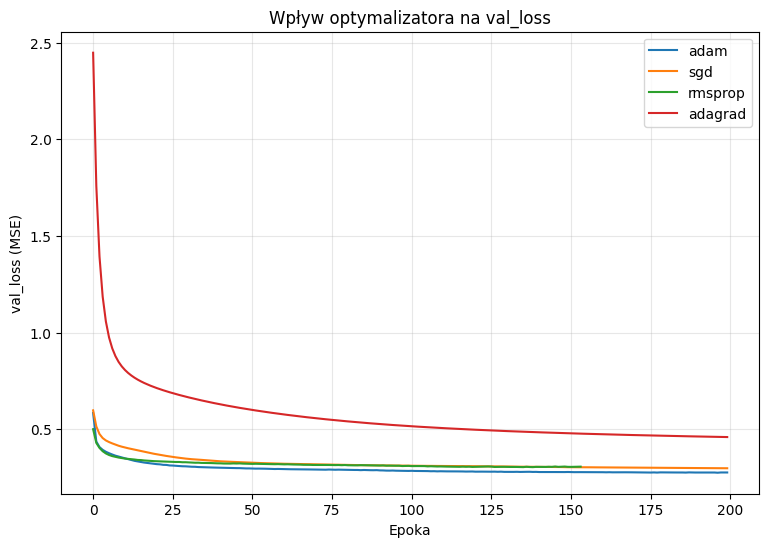

In [18]:
plt.figure(figsize=(9, 6))
for optymalizator in ['adam', 'sgd', 'rmsprop', 'adagrad']:
    historia = trenuj(buduj_mlp((64, 32)), optimizer=optymalizator)
    plt.plot(historia.history['val_loss'], label=optymalizator)
plt.title('Wpływ optymalizatora na val_loss')
plt.xlabel('Epoka')
plt.ylabel('val_loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Porównanie struktur sieci

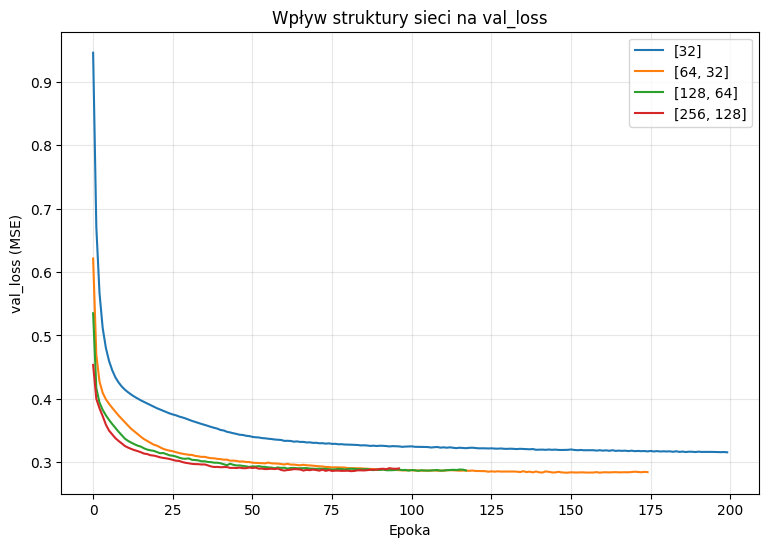

In [19]:
struktury = {'[32]': (32,), '[64, 32]': (64, 32), '[128, 64]': (128, 64), '[256, 128]': (256, 128)}
plt.figure(figsize=(9, 6))
for nazwa, warstwy in struktury.items():
    historia = trenuj(buduj_mlp(warstwy))
    plt.plot(historia.history['val_loss'], label=nazwa)
plt.title('Wpływ struktury sieci na val_loss')
plt.xlabel('Epoka')
plt.ylabel('val_loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11. Model finalny i ocena

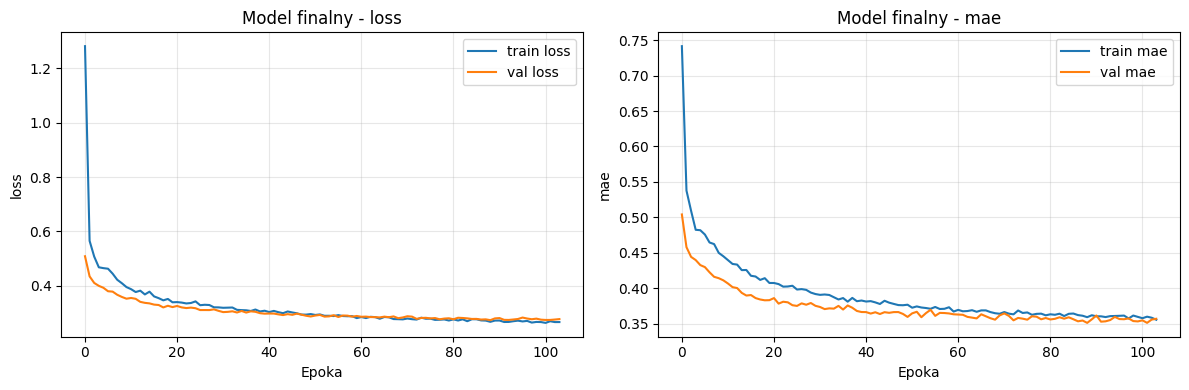

{'MSE': 0.26589359221060527, 'RMSE': 0.515648710083333, 'MAE': 0.3451907889412493, 'R2': 0.8060764349944649}


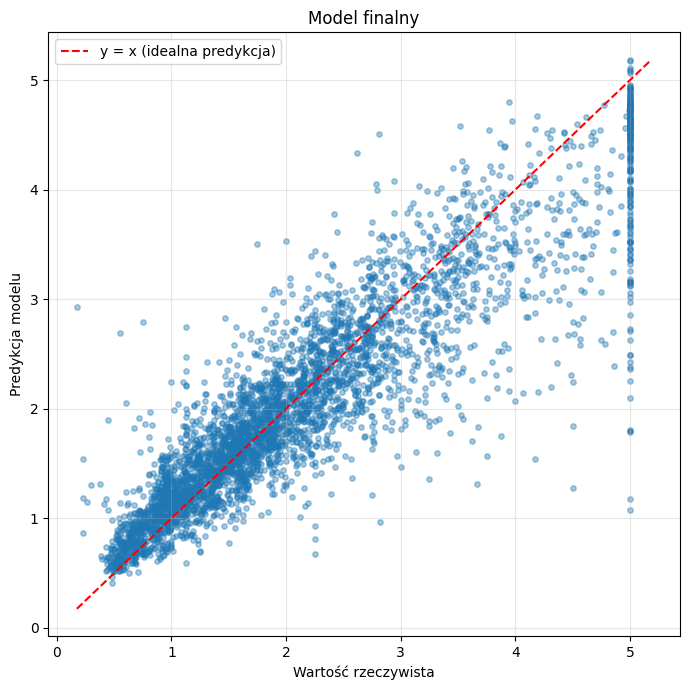

In [20]:
model_finalny = buduj_mlp(warstwy=(128, 64), dropout=0.2)
historia = trenuj(model_finalny)
wykres_krzywych_uczenia(historia, metryki=('loss', 'mae'), tytul='Model finalny')

pred_finalny = model_finalny.predict(X_test, verbose=0).ravel()
wyniki['MLP finalny'] = metryki_regresji(y_test, pred_finalny)
print(wyniki['MLP finalny'])

wykres_predykcja_vs_prawdziwa(y_test, pred_finalny, tytul='Model finalny')

## 12. Porównanie i wnioski

In [23]:
tabela = tabela_porownawcza(wyniki)
tabela.sort_values('RMSE')

,MSE,RMSE,MAE,R2
MLP Dropout,0.261362,0.511236,0.341807,0.809382
MLP finalny,0.265894,0.515649,0.345191,0.806076
MLP prosty,0.277786,0.527054,0.355273,0.797403
MLP BatchNorm,0.467419,0.683680,0.471679,0.659099
Regresja liniowa,0.554625,0.744731,0.533757,0.595497


**Wnioski:**
- **MLP wyraźnie bije regresję liniową** R² rośnie z 0.60 (model liniowy) do ~0.81 (MLP), więc sieć wychwytuje nieliniowe zależności w danych.
- **Najlepszy model: MLP + Dropout (128-64)** RMSE ≈ 0.51, R² ≈ 0.81. Dropout ograniczył przeuczenie bez utraty jakości.
- **BatchNorm tutaj zaszkodził** R² ≈ 0.66 wobec ~0.81 dla pozostałych sieci (choć wciąż lepiej niż regresja liniowa 0.60). Przyczyna: cechy są już wystandaryzowane (`StandardScaler`), więc zysk z BatchNorm jest niewielki, a normalizacja tuż przed wyjściem `Dense(1)` wprowadza szum mini-batcha i rozjazd statystyk treningu vs inferencji. Dla regresji tabelarycznej skuteczniejszy okazał się Dropout.
- **Optymalizator/struktura:** adam i rmsprop zbiegają najszybciej i najniżej; sieci 2-warstwowe (np. 128-64) wystarczają pogłębianie do 256-128 nie poprawia val_loss.
- **Wyzwania danych:** skośne cechy (dochód, populacja) i przycięcie targetu do 5.0 ograniczają górną dokładność.